In [54]:
import numpy as np
import tdgl
from tdgl.geometry import box, circle

length_units = "um"
xi, london_lambda, d = 0.25, 2, 0.1
layer = tdgl.Layer(coherence_length=xi, london_lambda=london_lambda,
                   thickness=d, gamma=1)

In [55]:
total_width, total_length = 5, 17.5
link_width = total_width / 3

right_notch = (tdgl.Polygon(points=box(total_width))
               .rotate(45)
               .translate(dx=(np.sqrt(2) * total_width + link_width) / 2))
left_notch = right_notch.scale(xfact=-1)

film = (tdgl.Polygon("film", points=box(total_width, total_length))
        .difference(right_notch, left_notch)
        .resample(401)
        .buffer(0))

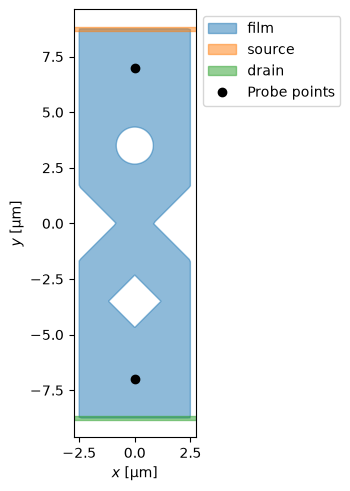

In [56]:
round_hole = tdgl.Polygon("round_hole", points=circle(link_width / 2)).translate(dy=total_length / 5)
square_hole = tdgl.Polygon("square_hole", points=box(link_width)).rotate(45).translate(dy=-total_length / 5)

source = tdgl.Polygon("source", points=box(1.1 * total_width, total_length / 100)).translate(dy=total_length / 2)
drain = source.scale(yfact=-1).set_name("drain")

probe_points = [(0, total_length / 2.5), (0, -total_length / 2.5)]

device = tdgl.Device("weak_link", layer=layer, film=film,
                     holes=[round_hole, square_hole],
                     terminals=[source, drain],
                     probe_points=probe_points,
                     length_units=length_units)
fig, ax = device.draw()